In [7]:
import plotly.graph_objects as go

# I used this function to make the figures better.
def update_plotly_layout(fig, y_axis_title, x_axis_title, legend_orientation = 'h', font_size=21,  legend_x_pos=0.3, legend_y_pos=1.1, height = 400, width=800) -> go.Figure:
    fig.update_layout(plot_bgcolor= "#FFFFFF",
                      yaxis=go.layout.YAxis(title=go.layout.yaxis.Title(text= y_axis_title, font=dict(family='Times New Roman', size= font_size, color='#000000')),
                                            color="#000000", tickfont=dict(family='Times New Roman', size= font_size)),
                      xaxis=go.layout.XAxis(title=go.layout.xaxis.Title(text= x_axis_title, font=dict(family='Times New Roman', size= font_size, color='#000000')), 
                                            color="#000000", tickfont=dict(family='Times New Roman', size= font_size)),
                      legend=dict(orientation = legend_orientation, x=legend_x_pos, y=legend_y_pos,  font=dict(family='Times New Roman', size= font_size), bgcolor="rgba(0,0,0,0)"),
                      
                      font=dict(family="Times New Roman", size= font_size), width = width, height = height)
    return fig

# Task 1

In [3]:
!pip install transformers torch datasets accelerate tqdm huggingface_hub bitsandbytes

# Task 2

In [4]:
!huggingface-cli version

⚠️  Warning: 'huggingface-cli version' is deprecated. Use 'hf version' instead.
huggingface_hub version: 0.36.0


# Task 3

In [7]:
############# I copied the codes of llama_mmlu_eval.py, ran, and verified it works.
############# Here was the output:


# /Users/wyd2hu/anaconda3/envs/AIAgentCourse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
#   from .autonotebook import tqdm as notebook_tqdm

# ======================================================================
# Llama 3.2-1B MMLU Evaluation (Quantized)
# ======================================================================

# ======================================================================
# Environment Check
# ======================================================================
# âœ“ Running locally (not in Colab)
# âœ“ Platform: Darwin (arm64)
# âœ“ Processor: arm
# âœ“ Apple Metal (MPS) Available
# âœ“ Using Metal Performance Shaders for GPU acceleration
# âœ“ Quantization disabled - loading full precision model
# âœ“ Hugging Face authenticated

# ======================================================================
# Configuration
# ======================================================================
# Model: meta-llama/Llama-3.2-1B-Instruct
# Device: mps
# Quantization: None (full precision)
# Expected memory: ~2.5 GB (FP16)
# Number of subjects: 2
# ======================================================================


# Loading model meta-llama/Llama-3.2-1B-Instruct...
# Device: mps
# âœ“ Tokenizer loaded
# Loading model (this may take 2-3 minutes)...
# âœ“ Model loaded successfully!
#   Model device: mps:0
#   Model dtype: torch.float16
#   Running on Apple Metal (MPS)

# ======================================================================
# Starting evaluation on 2 subjects
# ======================================================================


# Progress: 1/2 subjects

# ======================================================================
# Evaluating subject: astronomy
# ======================================================================
# Testing astronomy:   0%|          | 0/152 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
# Testing astronomy: 100%|██████████| 152/152 [00:17<00:00,  8.49it/s]
# âœ“ Result: 76/152 correct = 50.00%

# Progress: 2/2 subjects

# ======================================================================
# Evaluating subject: business_ethics
# ======================================================================
# Testing business_ethics: 100%|██████████| 100/100 [00:11<00:00,  8.79it/s]âœ“ Result: 45/100 correct = 45.00%

# ======================================================================
# EVALUATION SUMMARY
# ======================================================================
# Model: meta-llama/Llama-3.2-1B-Instruct
# None (full precision)
# Total Subjects: 2
# Total Questions: 252
# Total Correct: 121
# Overall Accuracy: 48.02%
# Duration: 0.5 minutes
# ======================================================================

# âœ“ Results saved to: llama_3.2_1b_mmlu_results_full_20260224_152130.json

# ðŸ“Š Top 5 Subjects:
#   1. astronomy: 50.00%
#   2. business_ethics: 45.00%

# ðŸ“‰ Bottom 5 Subjects:
#   1. astronomy: 50.00%
#   2. business_ethics: 45.00%

# âœ… Evaluation complete!

# Task 4

In [ ]:
############# I am using Mac and hence, did not work on 4 and 8 bit quantization.

# Clearly, the GPU usage takes least time, while CPU+quantization takes most time.

In [5]:
import sys
import subprocess
import tempfile
from pathlib import Path

import pandas as pd
import plotly.express as px

py_path = sys.executable
script_path = "task_4_llama_mmlu_eval.py"  # change if needed

def time_one_run(use_gpu: str, quant_bits, setup_name: str) -> dict:
    # quant_bits should be "none", 4, or 8
    quant_str = str(quant_bits).lower()

    time_file = tempfile.NamedTemporaryFile(delete=False)
    err_file = tempfile.NamedTemporaryFile(delete=False)
    time_path = time_file.name
    err_path = err_file.name
    time_file.close()
    err_file.close()

    # Put time output alone into time_path, and program stderr into err_path
    shell_cmd = f"""
                {{
                # Make bash 'time' print only the wall-clock seconds (a single number)
                TIMEFORMAT=%R

                # Run the script with env overrides:
                # - stdout -> /dev/null (hide normal prints)
                # - stderr -> err_path  (keep logs/errors separate)
                time env USE_GPU={use_gpu} QUANTIZATION_BITS={quant_str} \
                    "{py_path}" "{script_path}" \
                    1>/dev/null 2>"{err_path}"
                }} 2>"{time_path}"
                """.strip()

    completed = subprocess.run(["bash", "-lc", shell_cmd])

    time_text = Path(time_path).read_text().strip()
    err_text = Path(err_path).read_text()

    # Clean up temp files
    Path(time_path).unlink(missing_ok=True)
    Path(err_path).unlink(missing_ok=True)

    elapsed_sec = float(time_text.splitlines()[-1]) if time_text else None

    return {
        "setup": setup_name,
        "use_gpu": use_gpu,
        "quant_bits": None if quant_str == "none" else int(quant_str),
        "elapsed_sec": elapsed_sec,
        "return_code": completed.returncode,
        "stderr_tail": err_text[-500:]}

In [8]:
def complete_task_4():
    setups = [('1', "none", "GPU + no quant"),
              ('0', "none", "CPU + no quant"),
              ('0', 4,      "CPU + 4-bit")]

    results = [time_one_run(use_gpu, quant_bits, name) for use_gpu, quant_bits, name in setups]
    df_time = pd.DataFrame(results)

    # Keep only successful runs for plotting
    df_ok = df_time[df_time["return_code"] == 0].copy()
    df_ok

    fig = px.bar(df_ok, x="setup", y="elapsed_sec", text="elapsed_sec")
    fig.update_traces(texttemplate="%{text:.2f}s", textposition="outside")
    fig.update_layout(xaxis_title="", yaxis_title="Elapsed time (s)")

    fig = update_plotly_layout(fig, y_axis_title="Elapsed time (s)", x_axis_title="", height=1000)
    fig.show()


complete_task_4()

# Task 5

In [ ]:
# Added timing information (please, see the findings of Task 6. also, you may check the file "llama_3.2_1b_mmlu_results_4bit_20260301_150438.json").
# Added option to print out each question, the answer the model gives, and whether the answer is right or wrong (by  ✅, ❌). 

In [12]:
%run "task_5_modified_llama_mmlu_eval copy.py"


MMLU Evaluation (Quantized) - Multi-Model

Environment Check
✓ Running locally (not in Colab)
✓ Platform: Darwin (arm64)
✓ Processor: arm
✓ Apple Metal (MPS) Available
✓ Using Metal Performance Shaders for GPU acceleration
✓ Quantization disabled - loading full precision model
✓ Hugging Face authenticated

Configuration
Model: meta-llama/Llama-3.2-1B-Instruct
Device: mps
Quantization: None (full precision)
Expected memory: ~2.5 GB (FP16)
Number of subjects: 10


**********************************************************************
STARTING EVALUATION FOR: meta-llama/Llama-3.2-1B-Instruct
**********************************************************************


Loading model meta-llama/Llama-3.2-1B-Instruct...
Device: mps
✓ Tokenizer loaded
Loading model (this may take 2-3 minutes)...
✓ Model loaded successfully!
  Model device: mps:0
  Model dtype: torch.float16
  Running on Apple Metal (MPS)

Evaluating subject: astronomy. Model LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tok

Testing astronomy:   1%|▏         | 2/152 [00:00<00:39,  3.81it/s]


Q: What is true for a type-Ia ("type one-a") supernova?
Model Answer: C | Correct Answer: A
Correct? ❌ No

Q: If you know both the actual brightness of an object and its apparent brightness from your location then with no other information you can estimate:
Model Answer: D | Correct Answer: D
Correct? ✅ Yes


Testing astronomy:   3%|▎         | 4/152 [00:00<00:28,  5.10it/s]


Q: Why is the sky blue?
Model Answer: C | Correct Answer: C
Correct? ✅ Yes

Q: You’ve made a scientific theory that there is an attractive force between all objects. When will your theory be proven to be correct?
Model Answer: C | Correct Answer: C
Correct? ✅ Yes


...

Testing computer_security:  99%|█████████▉| 99/100 [00:33<00:00,  4.06it/s]


Q: The ______________ can cost you money, by sending text messages from your mobile phone numbers.
Model Answer: C | Correct Answer: C
Correct? ✅ Yes


Testing computer_security: 100%|██████████| 100/100 [00:33<00:00,  2.95it/s]


Q: Three of the following are classic security properties; which one is not?
Model Answer: C | Correct Answer: B
Correct? ❌ No
✓ Result: 61/100 correct = 61.00%

EVALUATION SUMMARY: Qwen/Qwen2.5-0.5B
Overall Accuracy: 43.34%
Real Time: 543.77 seconds
CPU Time: 483.69 seconds
GPU Time: 543.77 seconds



✅ All evaluations complete! Results saved to: multi_model_mmlu_results_full_20260301_153007.json


# Task 6

<!-- 
Here, I run these 3 models: "meta-llama/Llama-3.2-1B-Instruct", "google/gemma-2b", and "Qwen/Qwen2.5-0.5B".

Clearly, LLMa and Qwen has higher performance than Gemma. However, Qwen takes significantly higher time than the Gemma and LLMa in terms of real-time, GPU time, and CPU time.
Besides, it appears that both LLMa and Qwen makes significantly less mistakes than Gemma in almost all subjects.
On the other hand, though Llama and Qwen have very similar performance, Llama is significantly faster.

It appears that though Llama has a pretty good performance, it makes more mistakes in college physics.

The mistakes do not appear to be random. 
-->

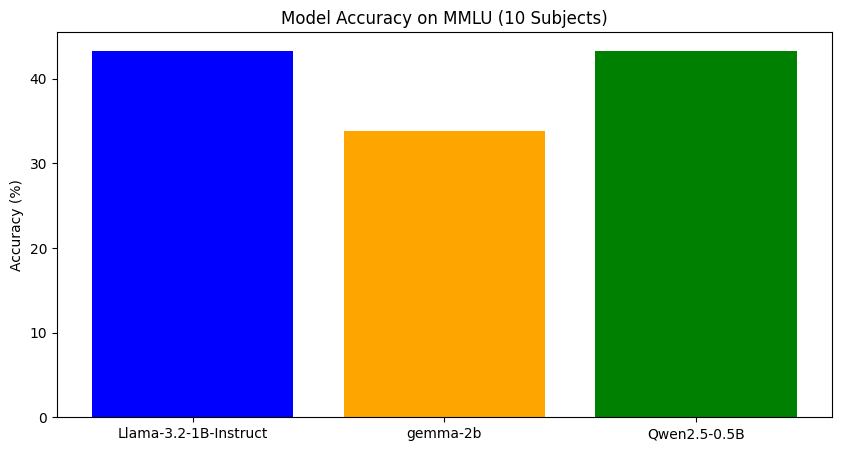

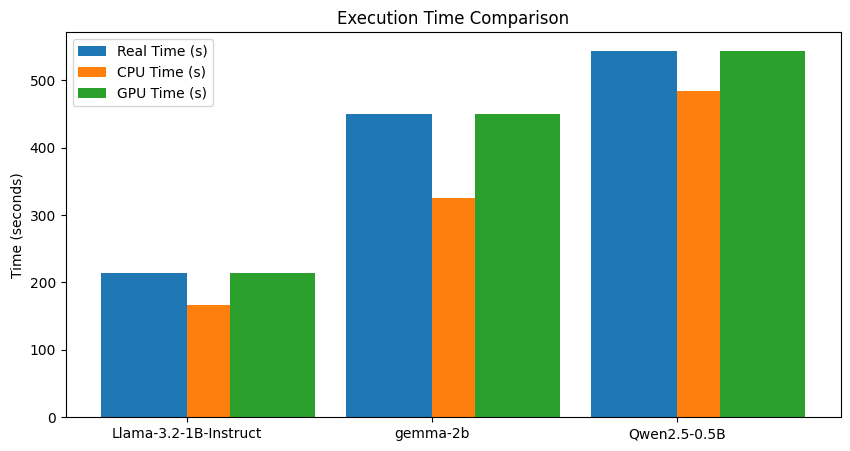


--- MISTAKE ANALYSIS ---
Llama-3.2-1B-Instruct total mistakes: 758
gemma-2b total mistakes: 884
Qwen2.5-0.5B total mistakes: 757

Number of questions ALL models got wrong: 391


In [14]:
import json
import matplotlib.pyplot as plt
import numpy as np
import sys

# Change this to the name of the JSON file generated by your run
RESULTS_FILE = "multi_model_mmlu_results_full_20260301_153007.json" # Example name

def plot_and_analyze():
    with open(RESULTS_FILE, 'r') as f:
        data = json.load(f)
        
    models = [d["model"].split("/")[-1] for d in data]
    accuracies = [d["overall_accuracy"] for d in data]
    real_times = [d["real_time_sec"] for d in data]
    cpu_times = [d["cpu_time_sec"] for d in data]
    gpu_times = [d["gpu_time_sec"] for d in data]
    
    # 1. Plot Accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(models, accuracies, color=['blue', 'orange', 'green'])
    plt.title("Model Accuracy on MMLU (10 Subjects)")
    plt.ylabel("Accuracy (%)")
    plt.savefig("accuracy_comparison.pdf") # Saves directly to PDF for your portfolio
    plt.show()
    
    # 2. Plot Timing
    x = np.arange(len(models))
    width = 0.35
    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, real_times, width, label='Real Time (s)')
    plt.bar(x + width/2, cpu_times, width, label='CPU Time (s)')
    plt.bar(x + width, gpu_times, width, label='GPU Time (s)')
    plt.xticks(x, models)
    plt.title("Execution Time Comparison")
    plt.ylabel("Time (seconds)")
    plt.legend()
    plt.savefig("timing_comparison.pdf")
    plt.show()
    
    # 3. Mistake Analysis
    print("\n--- MISTAKE ANALYSIS ---")
    model_mistakes = {} # Dict mapping model -> set of (subject, question_idx)
    
    for model_data in data:
        m_name = model_data["model"].split("/")[-1]
        mistakes = set()
        for sub in model_data["subject_results"]:
            for m_idx in sub["mistakes"]:
                mistakes.add((sub["subject"], m_idx))
        model_mistakes[m_name] = mistakes
        print(f"{m_name} total mistakes: {len(mistakes)}")

    if len(models) == 3:
        m1, m2, m3 = models[0], models[1], models[2]
        overlap_all = model_mistakes[m1].intersection(model_mistakes[m2]).intersection(model_mistakes[m3])
        print(f"\nNumber of questions ALL models got wrong: {len(overlap_all)}")

if __name__ == "__main__":
    plot_and_analyze()

In [15]:
import json
import pandas as pd
import plotly.graph_objects as go

def plot_mistake_heatmap():
    with open(RESULTS_FILE, 'r') as f:
        data = json.load(f)
        
    mistake_matrix = {}
    hover_text_matrix = {}
    
    # 1. Rebuild the data into a grid format for the heatmap
    for model_data in data:
        model_name = model_data["model"].split("/")[-1]
        model_mistakes = {}
        model_hover = {}
        
        for sub in model_data["subject_results"]:
            subject = sub["subject"]
            mistakes = set(sub["mistakes"])
            total_q = sub["total"]
            
            for q_idx in range(total_q):
                # Unique column name for every single question
                col_name = f"{subject}_Q{q_idx}"
                
                # 1 if mistake, 0 if correct
                is_mistake = 1 if q_idx in mistakes else 0
                model_mistakes[col_name] = is_mistake
                
                # Create the custom interactive hover text
                status = "Mistake" if is_mistake else "Correct"
                model_hover[col_name] = f"Subject: {subject}<br>Question Index: Q{q_idx}<br>Status: {status}"
                
        mistake_matrix[model_name] = model_mistakes
        hover_text_matrix[model_name] = model_hover

    # 2. Convert to Pandas DataFrames
    df = pd.DataFrame(mistake_matrix).T
    df_hover = pd.DataFrame(hover_text_matrix).T

    # 3. Plot the matrix using Plotly
    fig = go.Figure(data=go.Heatmap(
        z=df.values,
        x=df.columns,
        y=df.index,
        colorscale=[[0, "#ffffff"], [1, "#ff4444"]], # Custom colors: White (0) for correct, Red (1) for mistake
        showscale=False, # Hides the colorbar
        text=df_hover.values, # Injects the custom text matrix we built above
        hoverinfo="text" # Forces Plotly to only display our custom text
    ))

    # 4. Update the layout to match the aesthetics of your previous chart
    fig.update_layout(
        title="MMLU Mistake Patterns (Red = Mistake, White = Correct)",
        xaxis_title="Individual Questions (Hover to see subject)",
        yaxis_title="Models",
        xaxis=dict(showticklabels=False), # Hides the messy x-axis labels
        plot_bgcolor="lightgray",
        height=400,
        margin=dict(l=150, r=50, t=50, b=50)
    )
    
    # To view the interactive Plotly graph, you must use .show()
    # It will open in a new browser tab or natively inside your Jupyter Notebook
    fig.show()
    
    # Optional: You can also save it as an interactive HTML file to include in your portfolio
    # fig.write_html("mistake_patterns_heatmap.html")

if __name__ == "__main__":
    plot_mistake_heatmap()

# Task 7

In [ ]:
# I have run the codes in Google Colab and all findings are available in Topic_1_in_Colab.ipynb (inside the Files in Colab(Including Notebook)).
# There, I run the following 6 models

# "meta-llama/Llama-3.2-1B-Instruct",
# "mistralai/Mistral-7B-v0.1",
# "Qwen/Qwen2.5-7B-Instruct",
# "allenai/OLMo-2-1124-7B",
# "google/gemma-2b",
# "Qwen/Qwen2.5-0.5B".DS_Store


# A surpsing thing I noticed in colab is CPU+ no quantization took max time which is surprising to me, 
# since in mac the max time was consumed by CPU+quantization.

# Task 8

<!-- Sliding Window (Truncation) approach is implemented here, to prevent the chat history from growing without limit-->

<!-- 
As can be expected, when chat history is disabled, the Llama-3.2 can not remember anything I said before. 
For instance, as depicted below, I said my name first both in case of enabled and disabled chat history. In case of disabled, it was not able to remember my name later.
-->

In [16]:
%env USE_HISTORY=True
%run task_8_simple_chat_agent.py

env: USE_HISTORY=True
Loading model (this takes 1-2 minutes)...
✓ Model loaded! Using device: mps:0
Chat started! (History Enabled: True) Type 'quit' to end.

User:  Hi, I am Sabbir
Assistant: Hello Sabbir! How can I assist you today?

User:  What is my name?
Assistant: Your name is Sabbir, right?

User:  yes
Assistant: I'm glad I could get your name right, Sabbir! Is there something I can help you with or would you like to chat?

User:  exit

Goodbye!


In [1]:
%env USE_HISTORY=False
%run task_8_simple_chat_agent.py

env: USE_HISTORY=False


/Users/wyd2hu/anaconda3/envs/AIAgentCourse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model (this takes 1-2 minutes)...
✓ Model loaded! Using device: mps:0
Chat started! (History Enabled: False) Type 'quit' to end.

User:  Hi, I am Sabbir
Assistant: Hello Sabbir! How's it going? What brings you here today?

User:  What is my name?
Assistant: I don't have any information about your personal details, including your name. This conversation just started, and I don't retain any information from previous conversations. I'm happy to chat with you, though! What's on your mind?

User:  exit

Goodbye!


# Acknowledgement

In [ ]:
# I acknowledge that I have used GenAI very significantly to do the assignments/tasks of the topics. 
# However, I tried to understand the codes. Also, it is not that I just copied all tasks of the topic and pasted the outputs here. 
# I went step by step by understanding and debugging the things. 
# Moreover, I spent several hours to understand the things and complete the tasks per topic.
# Besides, I checked whether the results make sense. For instance, GPU is expected to take less time: do I see that in the results?


# Here are the prompts I used:
# All prompts of ChatGPT: https://chatgpt.com/share/699e17dc-2ba8-8012-8df0-9f3d01e19dd7
# Gemini Pro prompts: https://gemini.google.com/share/8d12db8db5b2

# If you face any problem in accessing the links, please let me know.